# FAO GAEZ Land Use Maps Generator
Some outputs from the original data are note ok, so these will be replaced using FAO GAEZ data, including:

|Crop|Reason|
|:---|:-----|
|Oil Palm | Land use raster wrong, missing important production zones like Indonesia|
|Tomatoes| SPAM yields overly high, distorting results for some countries |
|Potatoes| Same as tomatoes |
| Maize | Super high yields |
|Tobacco| High yields |

## Suitability Index Inventory
We start by generating a file with all the files we have

In [20]:
import os
import polars as pl
from sbtn_leaf.paths import data_path
import sbtn_leaf.map_plotting as mp
from pathlib import Path
import numpy as np
import rasterio
from rasterio.warp import reproject
from rasterio.enums import Resampling


project_root = Path.cwd().parents[1]   # adjust number

In [2]:
files_folder = "../data/crops/FAO_GAEZ/SuitIndex"
files_prefix = "GAEZ-V5.RES05-SIX.HP0120.AGERA5.HIST."
files_extension = ".tif"
TEC_LOOKUP = {
    "HILM": "high_input_irrigated",
    "HRLM": "high_input_rainfed",
    "LILM": "low_input_irrigated",
    "LRLM": "low_input_rainfed",
}

IRR_LOOKUP = {
    "HILM": "irr",
    "HRLM": "rf",
    "LILM": "irr",
    "LRLM": "rf",
}

In [3]:
crop_index = pl.read_csv(data_path("crops", "FAO_GAEZ", "FAO_GAEZ_croplist.csv")).drop(["description", "index"]).rename({"caption":"crop_name", "code": "crop_code"})

In [4]:
crop_index.head()

crop_code,crop_name
str,str
"""ALF""","""Alfalfa"""
"""BAN""","""Banana"""
"""BRL""","""Barley"""
"""BSG""","""Biomass sorghum"""
"""BCH""","""Brachiaria"""


In [5]:
folder_path = data_path("crops", "FAO_GAEZ", "SuitIndex")

In [6]:
output_rows = []

for file in os.listdir(folder_path):
    if not file.lower().endswith(".tif"):  # skip not tif files
        continue

    filename = Path(file).stem
    file_path = str(folder_path / Path(file))
    parts = filename.split(".")
    if len(parts) < 2:
            continue
    
    crop_code = parts[-2].strip().upper()
    tech_code = parts[-1].strip().upper()

    output_rows.append({
        "filename": file,
        "filepath": file_path,
        "crop_code": crop_code,
        "tech_code": tech_code,
        "technology": TEC_LOOKUP.get(tech_code),
        "irrigation_practice": IRR_LOOKUP.get(tech_code)
    })

df = pl.DataFrame(output_rows)

# Attach crop names
df = df.join(
     other=crop_index,
     on="crop_code",
     how="left"
)

In [7]:
df.head(2)

filename,filepath,crop_code,tech_code,technology,irrigation_practice,crop_name
str,str,str,str,str,str,str
"""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""ALF""","""HILM""","""high_input_irrigated""","""irr""","""Alfalfa"""
"""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""ALF""","""HRLM""","""high_input_rainfed""","""rf""","""Alfalfa"""


Storing it

In [8]:
csv_out_path = project_root / "data" / "crops" / "FAO_GAEZ" / "fao_gaez_crop_suitindex_list.csv"

df.write_csv(
    str(csv_out_path),
    separator=";"
)

In [9]:
fao_gaez_crops = df["crop_name"].unique()

## Attaching to our analyzed crops

In [21]:
sbtn_crops = pl.read_excel(data_path("crops","FAO_GAEZ", "crops_file_index.xlsx"))

Adding oil palm rainfed cause some reason is not there...

In [23]:
new_row = pl.DataFrame({
    "crop_name": ["Oil palm"],
    "crop_practice_string": ["rf"],
    "crop_type": ["permanent"],
    "irrigation_practice": ["rf"],
})

sbtn_crops = pl.concat([sbtn_crops, new_row])

There a few crop names that need adjustment from FAO GAEZ

In [24]:
CROP_RENAME = {
    "Citrus": "Orange",
    "Sugar cane": "Sugarcane",
    "White potato": "Potato",
}

crop_renaming = pl.DataFrame(
    {"fao_gaez_name": ["Citrus","Sugar cane", "White potato"],
    "sbtn_name": ["Orange", "Sugarcane", "Potato"]}
)

Some don't have matches and are kept the same, including:
- Apples
- Grapes

Updating this couple of names

In [25]:
df = (
    df
    .join(
        crop_renaming,
        left_on="crop_name",
        right_on="fao_gaez_name",
        how="left"
    )
    .with_columns(
        pl.coalesce(["sbtn_name", "crop_name"]).alias("crop_name")
    ).drop("sbtn_name")
)

Now, we need only the high input ones

In [26]:
df = df.filter(pl.col("technology").is_in(["high_input_irrigated","high_input_rainfed"]))

Adding the suitability index file

In [27]:
sbtn_crops = sbtn_crops.join(
    other=df,
    how="left",
    on = ["crop_name", "irrigation_practice"]
)

In [28]:
sbtn_crops.head()

crop_name,crop_practice_string,crop_type,irrigation_practice,filename,filepath,crop_code,tech_code,technology
str,str,str,str,str,str,str,str,str
"""Barley""","""irr_ron""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""HILM""","""high_input_irrigated"""
"""Barley""","""irr_roff""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""HILM""","""high_input_irrigated"""
"""Cabbage""","""irr""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""CAB""","""HILM""","""high_input_irrigated"""
"""Carrot""","""irr""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""CAR""","""HILM""","""high_input_irrigated"""
"""Cotton""","""irr""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""COT""","""HILM""","""high_input_irrigated"""


Eliminating apple and grapes

In [29]:
sbtn_crops = sbtn_crops.filter(pl.col("tech_code").is_not_null())

## Creating land use maps

### LU Generating function

In [30]:
def create_lu_raster(
    input_fao_raster_path: str,
    output_folder: str,
    output_name: None | str = None,
    fao_raster_str_id: str = "GAEZ-V5.RES05-SIX.HP0120.AGERA5.HIST.",
    uhth_path: str = str(data_path("CountryLayers","soc_uht_map.tif")),
    fao_water: int = 9,
    fao_notsuitable: int = 8,
    fao_si_max: int = 7,
    resampling_method: Resampling = Resampling.mode,
):
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    # --- open base (target grid) ---
    with rasterio.open(uhth_path) as base:
        base_profile = base.profile.copy()
        base_crs = base.crs
        base_transform = base.transform
        base_shape = (base.height, base.width)
        base_nodata = base.nodata

    # --- open FAO raster (source grid) ---
    with rasterio.open(input_fao_raster_path) as fao:
        fao_crs = fao.crs
        fao_transform = fao.transform
        fao_data = fao.read(1)
        fao_nodata = fao.nodata

    # --- build binary on FAO grid ---
    suitable_mask = (
        (fao_data != fao_nodata)
        & (fao_data != fao_water)
        & (fao_data != fao_notsuitable)
        & (fao_data <= fao_si_max)   # <= is usually what you want
    )

    lu_src = np.where(suitable_mask, 1, 0).astype("uint8")

    # --- reproject/resample onto base grid ---
    lu_dst = np.full(base_shape, 0, dtype="uint8")  # binary output; choose 0 as background

    reproject(
        source=lu_src,
        destination=lu_dst,
        src_transform=fao_transform,
        src_crs=fao_crs,
        src_nodata=0,
        dst_transform=base_transform,
        dst_crs=base_crs,
        dst_nodata=0,
        resampling=resampling_method,
    )

    # --- construct output name ---
    if output_name is None:
        fname = Path(input_fao_raster_path).name
        lu_name = fname.split(fao_raster_str_id, 1)[1].rsplit(".tif", 1)[0]
        output_file = f"{lu_name}.tif"
    else:
        output_file = f"{output_name}.tif"

    output_path = f'{output_folder}/{output_file}'

    # --- update profile for binary output ---
    out_profile = base_profile.copy()
    out_profile.update(
        dtype="uint8",
        count=1,
        nodata=0,
        compress="lzw",
    )

    with rasterio.open(output_path, "w", **out_profile) as dst:
        dst.write(lu_dst, 1)

    return str(output_path)


### Going through all the files in the excel

In [31]:
output_folder = str(data_path("land_use","FAO_GAEZ"))

In [32]:
for row in sbtn_crops.iter_rows(named=True):
    input_raster = row["filepath"]
    crop_name = row["crop_name"]
    practice_id = row["crop_practice_string"]

    output_name = f"lu_gaez_{crop_name}_{practice_id}"

    print(f"Creating FAO GAEZ v5 based land use map for {crop_name}_{practice_id}")
    create_lu_raster(
        input_fao_raster_path = input_raster,
        output_folder = output_folder,
        output_name = output_name
    )

print("\nFinished!")

Creating FAO GAEZ v5 based land use map for Barley_irr_ron
Creating FAO GAEZ v5 based land use map for Barley_irr_roff
Creating FAO GAEZ v5 based land use map for Cabbage_irr
Creating FAO GAEZ v5 based land use map for Carrot_irr
Creating FAO GAEZ v5 based land use map for Cotton_irr
Creating FAO GAEZ v5 based land use map for Maize_irr_ron
Creating FAO GAEZ v5 based land use map for Maize_irr_roff
Creating FAO GAEZ v5 based land use map for Onion_irr
Creating FAO GAEZ v5 based land use map for Potato_irr
Creating FAO GAEZ v5 based land use map for Rapeseed_irr_ron
Creating FAO GAEZ v5 based land use map for Sorghum_irr_ron
Creating FAO GAEZ v5 based land use map for Sorghum_irr_roff
Creating FAO GAEZ v5 based land use map for Soybean_irr
Creating FAO GAEZ v5 based land use map for Sugar beet_irr
Creating FAO GAEZ v5 based land use map for Sunflower_irr
Creating FAO GAEZ v5 based land use map for Sweet potato_irr
Creating FAO GAEZ v5 based land use map for Tobacco_irr
Creating FAO GAEZ

Checking some outputs

Raster has 1 unique values. Min: 1.00. Max: 1.00


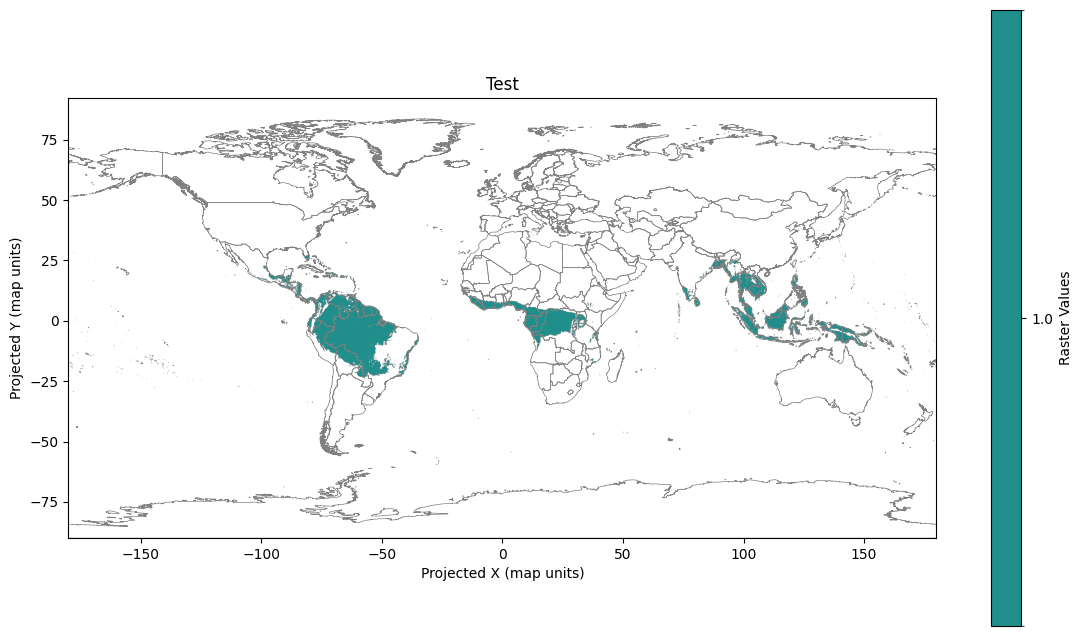

In [35]:
mp.plot_raster_on_world_extremes_cutoff("../../data/land_use/FAO_GAEZ/lu_gaez_Oil palm_rf.tif", "Test")

Raster has 1 unique values. Min: 1.00. Max: 1.00


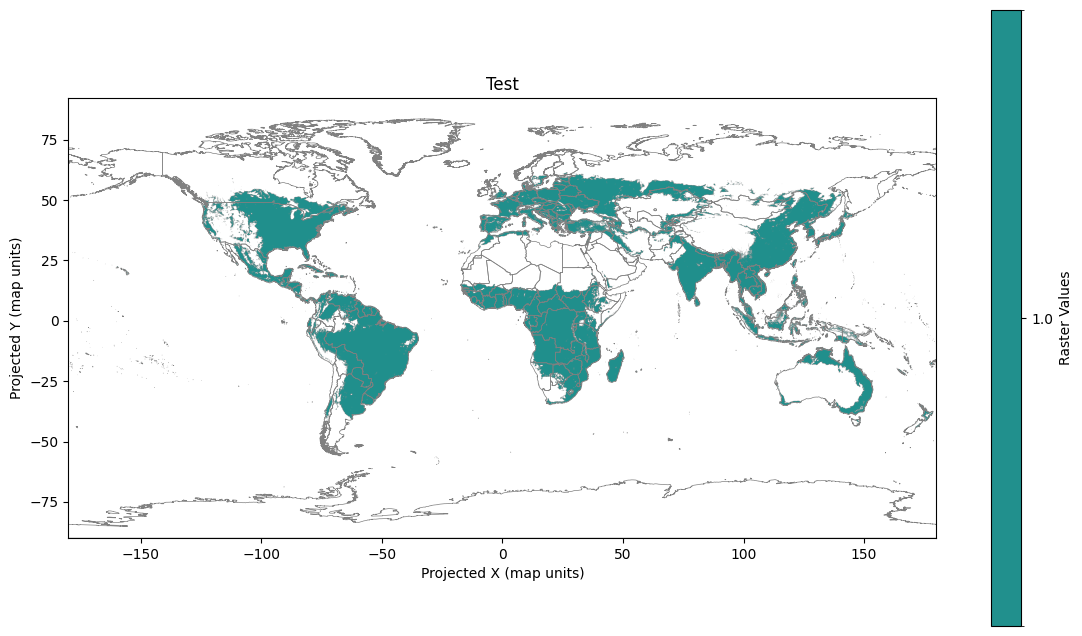

In [36]:
mp.plot_raster_on_world_extremes_cutoff("../../data/land_use/FAO_GAEZ/lu_gaez_Tomato_rf.tif", "Test")